In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

C:\Users\shami\AppData\Local\Temp\ipykernel_19436\775156109.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
import sys
!{sys.executable} -m pip install -U kaleido


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import kaleido
print("Kaleido is installed")

Kaleido is installed


c:\Users\shami\AppData\Local\Programs\Python\Python312\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning: 


This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.

  from .kaleido import Kaleido


In [5]:
import os
import warnings

warnings.filterwarnings("ignore")

# Create folder for exported charts
charts_path = "../reports/charts"
os.makedirs(charts_path, exist_ok=True)

print("Charts folder ready:", charts_path)

Charts folder ready: ../reports/charts


In [6]:
processed_path = "../data/processed/"

nav = pd.read_csv(processed_path + "clean_nav.csv")
transactions = pd.read_csv(processed_path + "clean_transactions.csv")
performance = pd.read_csv(processed_path + "clean_performance.csv")
fund_master = pd.read_csv(processed_path + "clean_fund_master.csv")
aum = pd.read_csv(processed_path + "clean_aum_by_fund_house.csv")
sip = pd.read_csv(processed_path + "clean_monthly_sip.csv")
category = pd.read_csv(processed_path + "clean_category.csv")
folio = pd.read_csv(processed_path + "clean_industry_folio_count.csv")
portfolio = pd.read_csv(processed_path + "clean_portfolio.csv")
benchmark = pd.read_csv(processed_path + "clean_benchmark.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [7]:
datasets = {
    "NAV": nav,
    "Transactions": transactions,
    "Performance": performance,
    "Fund Master": fund_master,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")
    print("Columns:", list(df.columns))
    print("-" * 80)

NAV: (46000, 3)
Columns: ['amfi_code', 'date', 'nav']
--------------------------------------------------------------------------------
Transactions: (32778, 13)
Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
--------------------------------------------------------------------------------
Performance: (40, 19)
Columns: ['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
--------------------------------------------------------------------------------
Fund Master: (40, 15)
Columns: ['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio

## Task 1: NAV Trend Analysis

Analyze daily NAV trends for all 40 mutual fund schemes from 2022 to 2026.
The analysis highlights the post-COVID recovery in 2022, the 2023 bull run,
and the 2024 market correction period.

In [8]:

# Convert date to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort data by scheme and date
nav = nav.sort_values(["amfi_code", "date"])

# Check the data
print("Date range:", nav["date"].min(), "to", nav["date"].max())
print("Number of schemes:", nav["amfi_code"].nunique())
print("Number of records:", len(nav))

Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00
Number of schemes: 40
Number of records: 46000


In [9]:
# Merge scheme names from Fund Master
nav_analysis = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Check result
print(nav_analysis.shape)
print(nav_analysis[["amfi_code", "scheme_name", "date", "nav"]].head())

(46000, 4)
   amfi_code                                scheme_name       date       nav
0     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-03  520.4608
1     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-04  515.0971
2     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-05  521.7239
3     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-06  515.7880
4     100016  HDFC Top 100 Fund - Regular Plan - Growth 2022-01-07  515.1639


In [10]:
print("Missing scheme names:", nav_analysis["scheme_name"].isna().sum())

Missing scheme names: 0


In [11]:
print("Number of schemes:", nav_analysis["scheme_name"].nunique())

nav_analysis["scheme_name"].unique()

Number of schemes: 40


array(['HDFC Top 100 Fund - Regular Plan - Growth',
       'HDFC Short Term Debt Fund - Regular - Growth',
       'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
       'ABSL Frontline Equity Fund - Regular - Growth',
       'ABSL Small Cap Fund - Regular - Growth',
       'ABSL Liquid Fund - Regular - Growth',
       'UTI Nifty 50 Index Fund - Regular - Growth',
       'UTI Mid Cap Fund - Regular - Growth',
       'UTI Flexi Cap Fund - Regular - Growth',
       'Nippon India Large Cap Fund - Regular - Growth',
       'Nippon India Large Cap Fund - Direct - Growth',
       'Nippon India Small Cap Fund - Regular - Growth',
       'Nippon India ETF Nifty 50 BeES',
       'Nippon India Gilt Securities Fund - Regular - Growth',
       'Axis Bluechip Fund - Regular - Growth',
       'Axis Bluechip Fund - Direct - Growth',
       'Axis Midcap Fund - Regular - Growth',
       'Axis Small Cap Fund - Regular - Growth',
       'SBI Magnum Gilt Fund - Regular Plan - Growth',
       'SBI Blu

Create the Matplotlib NAV Trend Chart

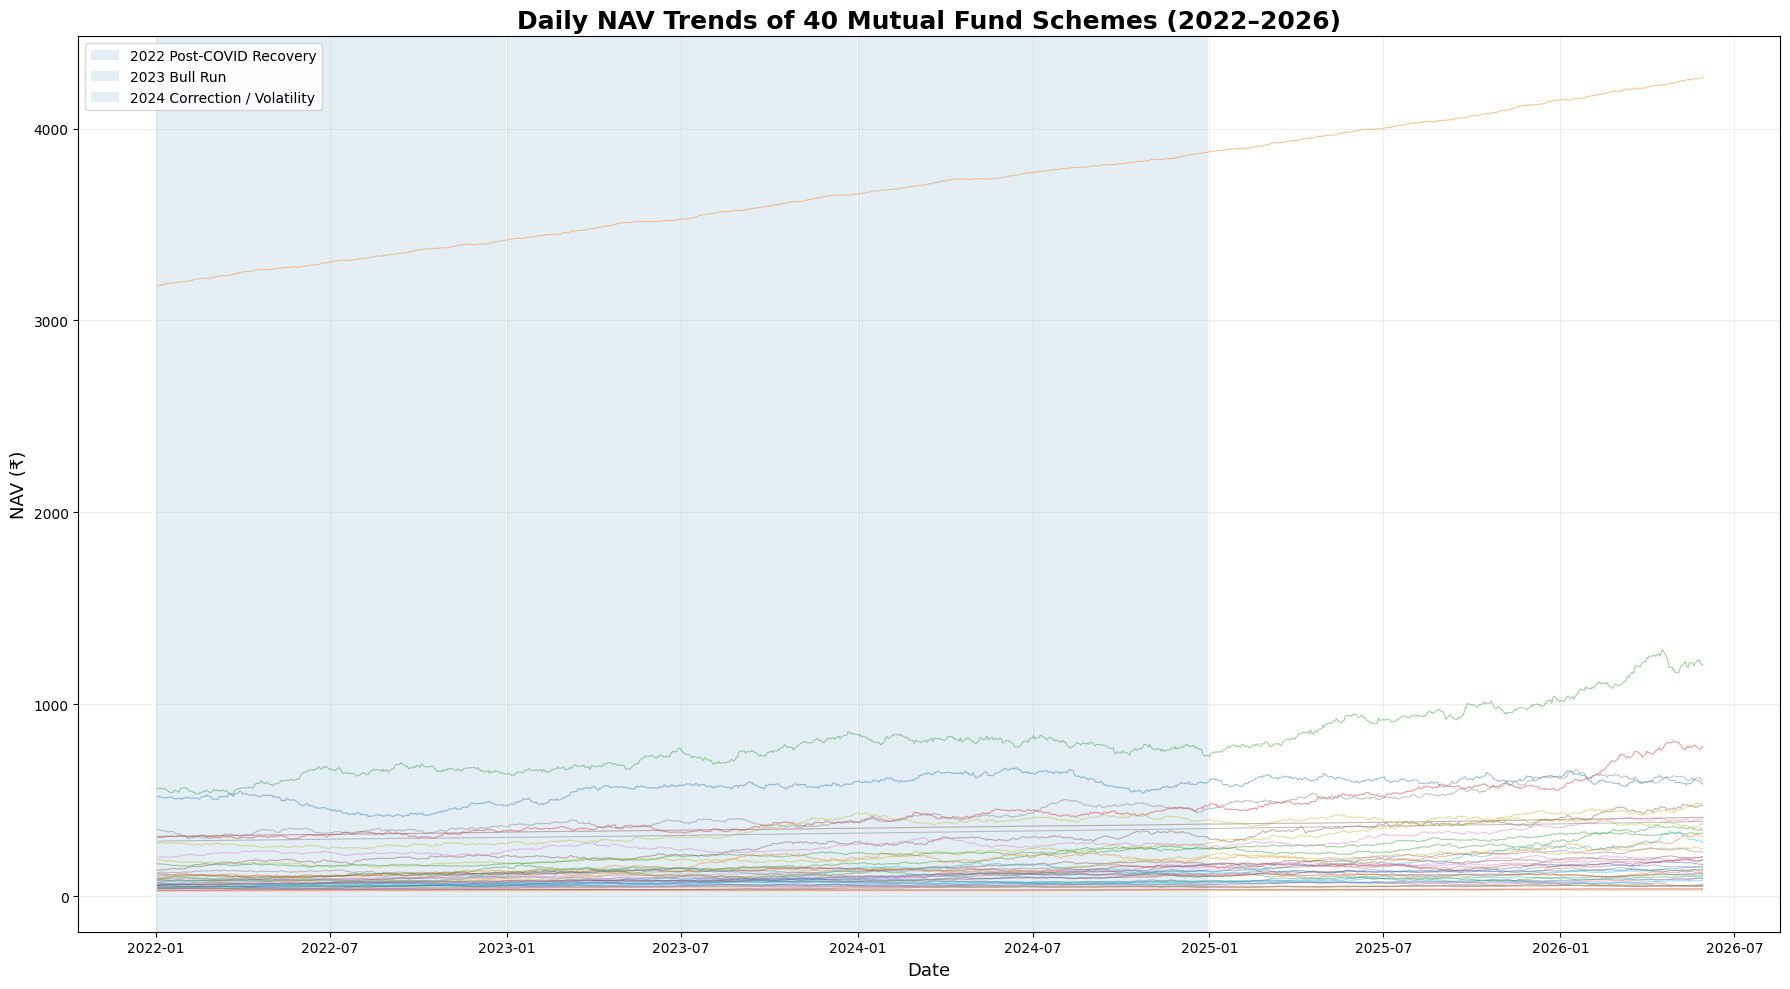

In [12]:
# Create figure
plt.figure(figsize=(18, 10))

# Plot all 40 schemes
for scheme in nav_analysis["scheme_name"].unique():
    
    scheme_data = nav_analysis[
        nav_analysis["scheme_name"] == scheme
    ]
    
    plt.plot(
        scheme_data["date"],
        scheme_data["nav"],
        linewidth=0.8,
        alpha=0.45
    )

# Highlight important market periods

# Post-COVID recovery
plt.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-12-31"),
    alpha=0.12,
    label="2022 Post-COVID Recovery"
)

# 2023 rally
plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.12,
    label="2023 Bull Run"
)

# 2024 correction
plt.axvspan(
    pd.Timestamp("2024-01-01"),
    pd.Timestamp("2024-12-31"),
    alpha=0.12,
    label="2024 Correction / Volatility"
)

# Chart title
plt.title(
    "Daily NAV Trends of 40 Mutual Fund Schemes (2022–2026)",
    fontsize=18,
    fontweight="bold"
)

# Axis labels
plt.xlabel("Date", fontsize=13)
plt.ylabel("NAV (₹)", fontsize=13)

# Grid
plt.grid(
    True,
    alpha=0.2
)

# Legend
plt.legend(
    loc="upper left"
)

# Improve layout
plt.tight_layout()

# Save chart
plt.savefig(
    os.path.join(charts_path, " NAV Trend Lines.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Create the Plotly interactive version

In [13]:
fig = px.line(
    nav_analysis,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trends of 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV (₹)",
        "scheme_name": "Scheme"
    }
)

fig.update_layout(
    width=1600,
    height=800,
    hovermode="x unified",
    template="plotly_white"
)

fig.show()

fig.write_html(
    os.path.join(
        charts_path,
        "NAV Trend Lines.html"
    )
)

AUM growth bar chart: Grouped bar chart — AUM by fund house for each year 2022–2025. Highlight SBI'sdominance at Rs.12.5L Cr.

In [14]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [15]:
print("Shape:", aum.shape)
print("Date range:", aum["date"].min(), "to", aum["date"].max())
print("Fund houses:", aum["fund_house"].nunique())
print(aum["fund_house"].unique())

Shape: (90, 5)
Date range: 2022-03-31 to 2025-12-31
Fund houses: 10
['SBI Mutual Fund' 'ICICI Prudential MF' 'HDFC Mutual Fund'
 'Nippon India MF' 'Kotak Mahindra MF' 'Aditya Birla Sun Life MF'
 'Axis Mutual Fund' 'UTI Mutual Fund' 'Mirae Asset MF' 'DSP Mutual Fund']


In [16]:
# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"], errors="coerce")

# Extract year
aum["year"] = aum["date"].dt.year

# Keep 2022–2025
aum_analysis = aum[
    aum["year"].between(2022, 2025)
].copy()

# Get the latest available AUM for each fund house in each year
year_end_aum = (
    aum_analysis
    .sort_values("date")
    .groupby(["year", "fund_house"], as_index=False)
    .tail(1)
)

year_end_aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
19,2022-09-30,DSP Mutual Fund,1.12,112000,88,2022
18,2022-09-30,Mirae Asset MF,1.08,108000,56,2022
17,2022-09-30,UTI Mutual Fund,2.32,232000,142,2022
16,2022-09-30,Axis Mutual Fund,2.40,240000,95,2022
15,2022-09-30,Aditya Birla Sun Life MF,2.85,285000,199,2022


SBI fund house: ['SBI Mutual Fund']


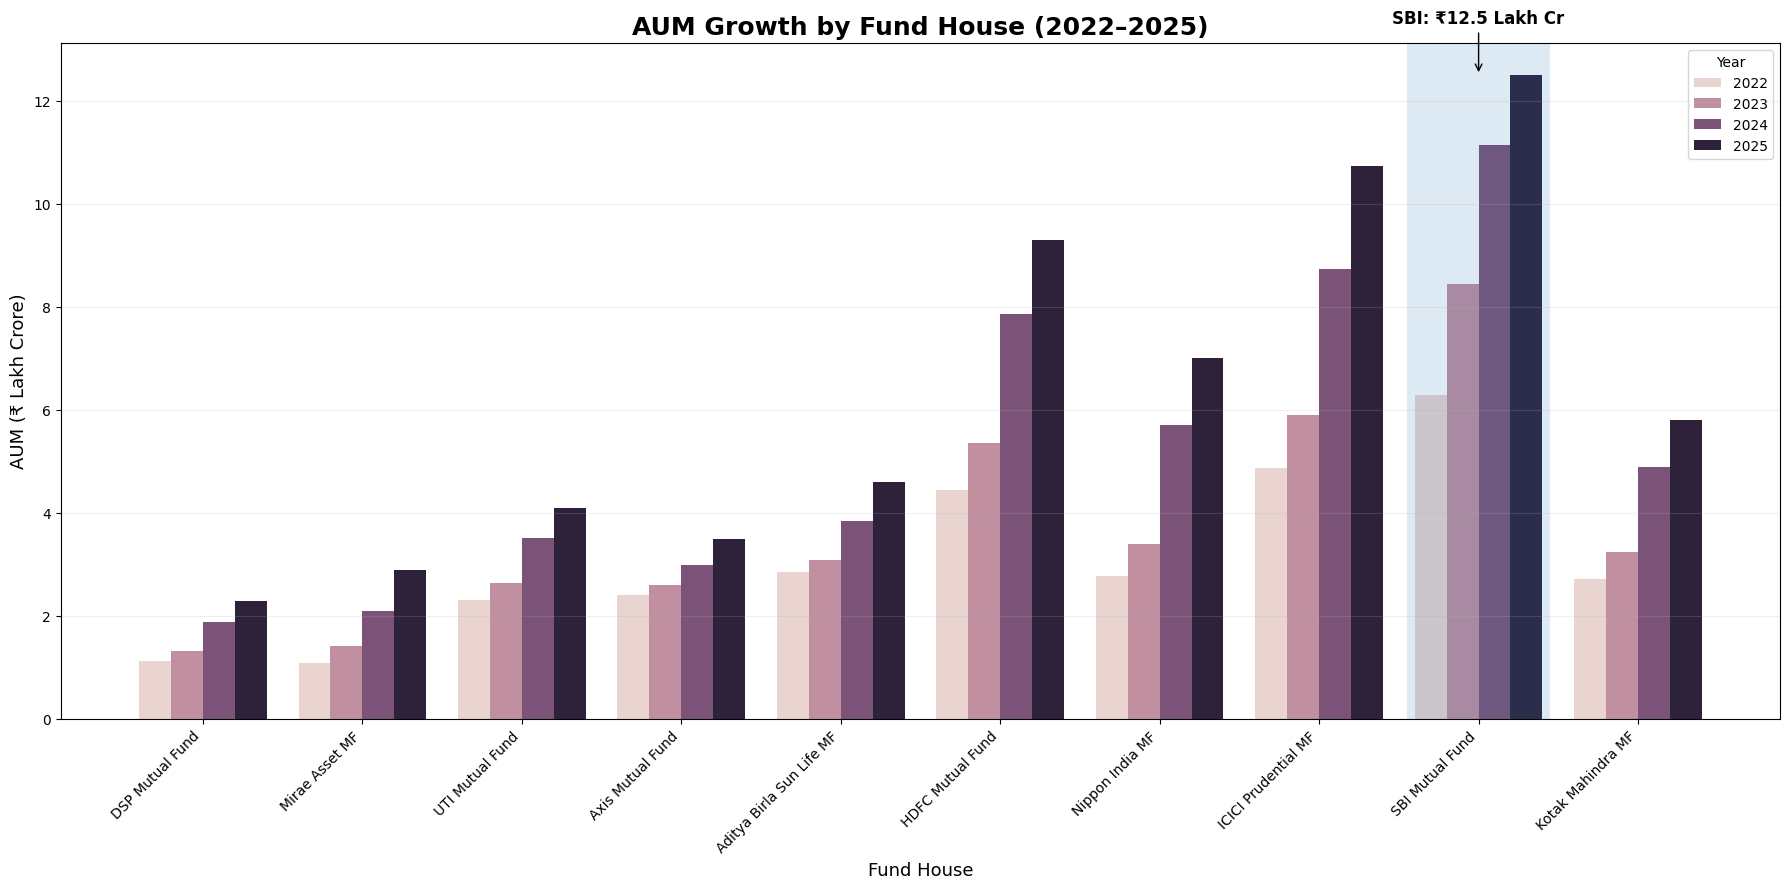

In [17]:
plt.figure(figsize=(18, 9))

# Grouped bar chart
ax = sns.barplot(
    data=year_end_aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    errorbar=None
)

# Find SBI's position
fund_houses = list(year_end_aum["fund_house"].unique())

sbi_names = [
    name for name in fund_houses
    if "SBI" in str(name).upper()
]

print("SBI fund house:", sbi_names)

# Highlight SBI
if sbi_names:
    sbi_index = fund_houses.index(sbi_names[0])

    ax.axvspan(
        sbi_index - 0.45,
        sbi_index + 0.45,
        alpha=0.15
    )

    # Get SBI's 2025 AUM
    sbi_2025 = year_end_aum[
        (year_end_aum["fund_house"] == sbi_names[0]) &
        (year_end_aum["year"] == 2025)
    ]

    if not sbi_2025.empty:
        sbi_value = sbi_2025.iloc[0]["aum_lakh_crore"]

        # SBI 2025 annotation
        ax.annotate(
            f"SBI: ₹{sbi_value:.1f} Lakh Cr",
            xy=(sbi_index, sbi_value),
            xytext=(sbi_index, sbi_value + 1),
            ha="center",
            fontsize=12,
            fontweight="bold",
            arrowprops=dict(
                arrowstyle="->"
            )
        )

# Title
plt.title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Fund House",
    fontsize=13
)

plt.ylabel(
    "AUM (₹ Lakh Crore)",
    fontsize=13
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Year"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        charts_path,
        "AUM Growth by AMC.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SIP inflow time-series: Monthly SIP inflow Jan 2022 to Dec 2025. Mark the Rs.31,002 Cr milestone (Dec 2025).

In [18]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [19]:
print("Shape:", sip.shape)
print("\nColumns:")
print(sip.columns.tolist())

print("\nMissing values:")
print(sip.isnull().sum())

Shape: (48, 6)

Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Missing values:
month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64


In [20]:
sip["month"] = pd.to_datetime(
    sip["month"],
    errors="coerce"
)

print("Start:", sip["month"].min())
print("End:", sip["month"].max())

Start: 2022-01-01 00:00:00
End: 2025-12-01 00:00:00


In [21]:
sip = sip.sort_values("month").reset_index(drop=True)
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [22]:
sip.tail()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
43,2025-08-01,28265,8.85,9.80,15.18,20.04
44,2025-09-01,29361,9.00,10.50,15.38,19.80
45,2025-10-01,29529,9.10,9.45,15.55,16.61
46,2025-11-01,30200,9.20,9.10,15.72,19.27
47,2025-12-01,31002,9.35,9.80,15.90,17.17


In [23]:
max_sip = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print("Maximum SIP Inflow:")
print("Month:", max_sip["month"])
print("SIP Inflow:", max_sip["sip_inflow_crore"], "Cr")

Maximum SIP Inflow:
Month: 2025-12-01 00:00:00
SIP Inflow: 31002 Cr


In [24]:
# Create SIP Inflow Trend Chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Line and marker formatting
fig.update_traces(
    line_width=3,
    marker_size=6
)

# Find highest SIP inflow
max_value = max_sip["sip_inflow_crore"]
max_month = max_sip["month"]

# Highlight highest SIP inflow
fig.add_annotation(
    x=max_month,
    y=max_value,
    text=f"Highest: ₹{max_value:,.0f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=-100,
    ay=-80,
    font=dict(size=14)
)

# Add ₹31,002 Cr milestone line
fig.add_hline(
    y=31002,
    line_dash="dash",
    annotation_text="₹31,002 Cr Milestone",
    annotation_position="top left"
)

fig.update_layout(
    width=1500,
    height=700,
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

fig.write_html(
    os.path.join(
        charts_path,
        " SIP Inflow Trend.html"
    )
)

Category-wise inflow heatmap: Months on X-axis, categories on Y-axis, net inflow as colour intensity.

In [25]:
# Check category dataset
print("Shape:", category.shape)
print("\nColumns:")
print(category.columns.tolist())

print("\nDate range:")
print(category["month"].min(), "to", category["month"].max())

print("\nCategories:")
print(category["category"].unique())

Shape: (144, 3)

Columns:
['month', 'category', 'net_inflow_crore']

Date range:
2024-04-01 to 2025-03-01

Categories:
['Large Cap' 'Mid Cap' 'Small Cap' 'Flexi Cap' 'Large & Mid Cap' 'ELSS'
 'Value/Contra' 'Sectoral/Thematic' 'Liquid' 'Short Duration' 'Gilt'
 'Hybrid']


In [26]:
# Convert month to datetime
category["month"] = pd.to_datetime(
    category["month"],
    errors="coerce"
)

# Sort by month and category
category = category.sort_values(
    ["month", "category"]
).reset_index(drop=True)

print("Date range:", category["month"].min(), "to", category["month"].max())
print("Number of categories:", category["category"].nunique())

Date range: 2024-04-01 00:00:00 to 2025-03-01 00:00:00
Number of categories: 12


In [27]:
# Create pivot table for heatmap
category_heatmap = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

category_heatmap

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


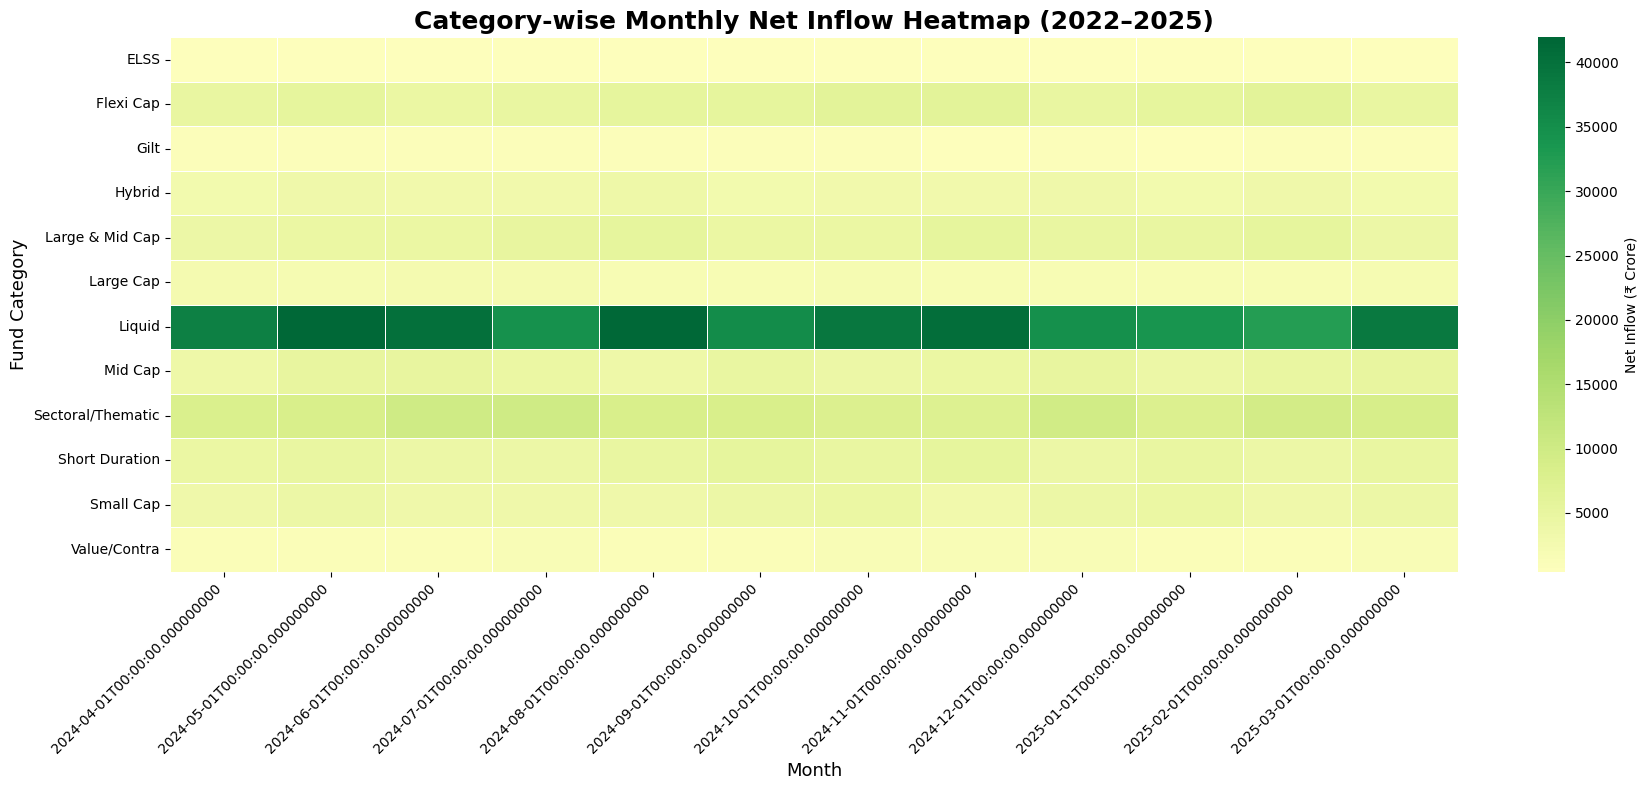

In [28]:
plt.figure(figsize=(18, 8))

ax = sns.heatmap(
    category_heatmap,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={
        "label": "Net Inflow (₹ Crore)"
    }
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap (2022–2025)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Month",
    fontsize=13
)

plt.ylabel(
    "Fund Category",
    fontsize=13
)

# Format X-axis labels
plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

# Save chart
plt.savefig(
    os.path.join(
        charts_path,
        "Category Heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Investor demographics: Age group distribution pie chart. SIP amount box plot by age group. Matplotlib, Seaborn 2 Charts: Demographics

In [29]:
print("Shape:", transactions.shape)

print("\nRelevant columns:")
print(
    transactions[
        ["age_group", "gender", "amount_inr"]
    ].head()
)

print("\nAge groups:")
print(transactions["age_group"].value_counts())

print("\nGender:")
print(transactions["gender"].value_counts())

Shape: (32778, 13)

Relevant columns:
  age_group  gender  amount_inr
0       56+  Female        1834
1     18-25    Male      392882
2     36-45    Male         912
3     36-45  Female        1102
4     26-35    Male        8682

Age groups:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Gender:
gender
Male      21809
Female    10969
Name: count, dtype: int64


Chart 1: Age Group Distribution

In [30]:
age_counts = transactions["age_group"].value_counts()
print(age_counts)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


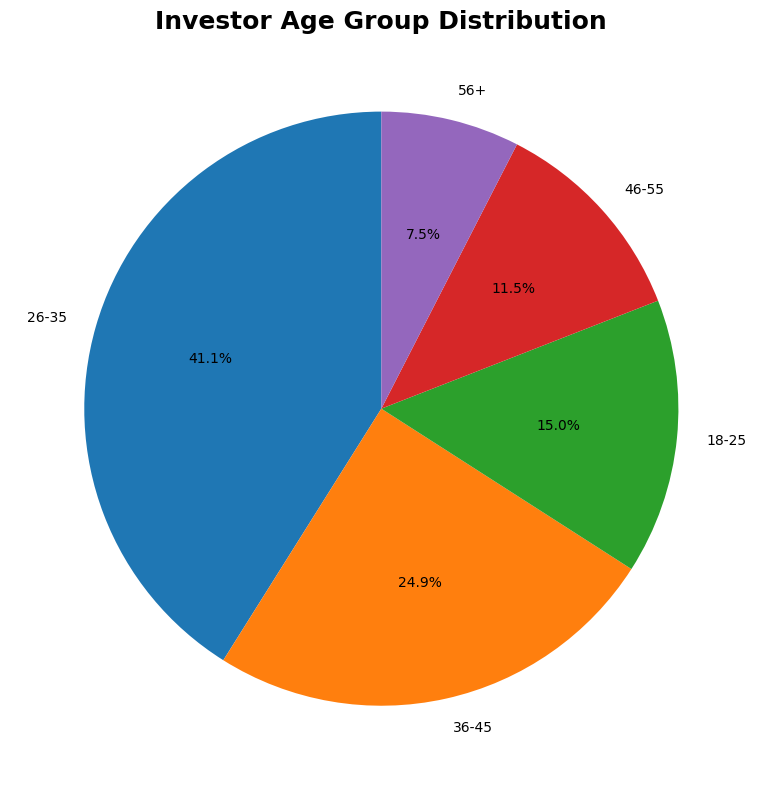

In [31]:
plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Age Group Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        charts_path,
        "Demographics_investor.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
print(transactions["transaction_type"].value_counts())

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64


Chart 2: SIP Amount by Age Group

In [33]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

print("SIP transactions:", len(sip_transactions))

SIP transactions: 19716


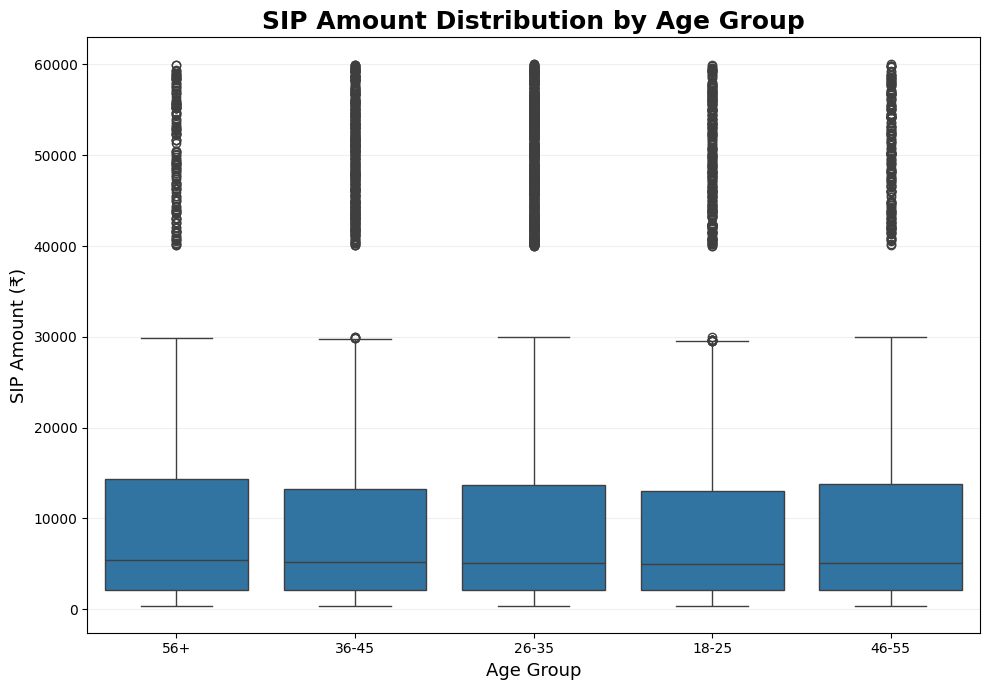

In [34]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Age Group",
    fontsize=13
)

plt.ylabel(
    "SIP Amount (₹)",
    fontsize=13
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        charts_path,
        "Demographics_sip.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
gender_counts = transactions["gender"].value_counts()

print("Gender Split:")
print(gender_counts)

print("\nGender Percentage:")
print(
    (gender_counts / gender_counts.sum() * 100).round(2)
)

Gender Split:
gender
Male      21809
Female    10969
Name: count, dtype: int64

Gender Percentage:
gender
Male      66.54
Female    33.46
Name: count, dtype: float64


Geographic distribution: Horizontal bar chart — SIP amount by state. T30 vs B30 pie chart.

In [36]:
print("SIP transactions:", len(sip_transactions))

SIP transactions: 19716


Chart 1 — SIP Amount by State

In [37]:
sip_state = (
    sip_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

print(sip_state)

state
Maharashtra       16445629
Rajasthan         16544233
Delhi             17113608
West Bengal       17495769
Uttar Pradesh     17534858
Karnataka         17696903
Haryana           18176696
Gujarat           18378904
Tamil Nadu        18404368
Telangana         18620216
Punjab            20140064
Madhya Pradesh    20682243
Name: amount_inr, dtype: int64


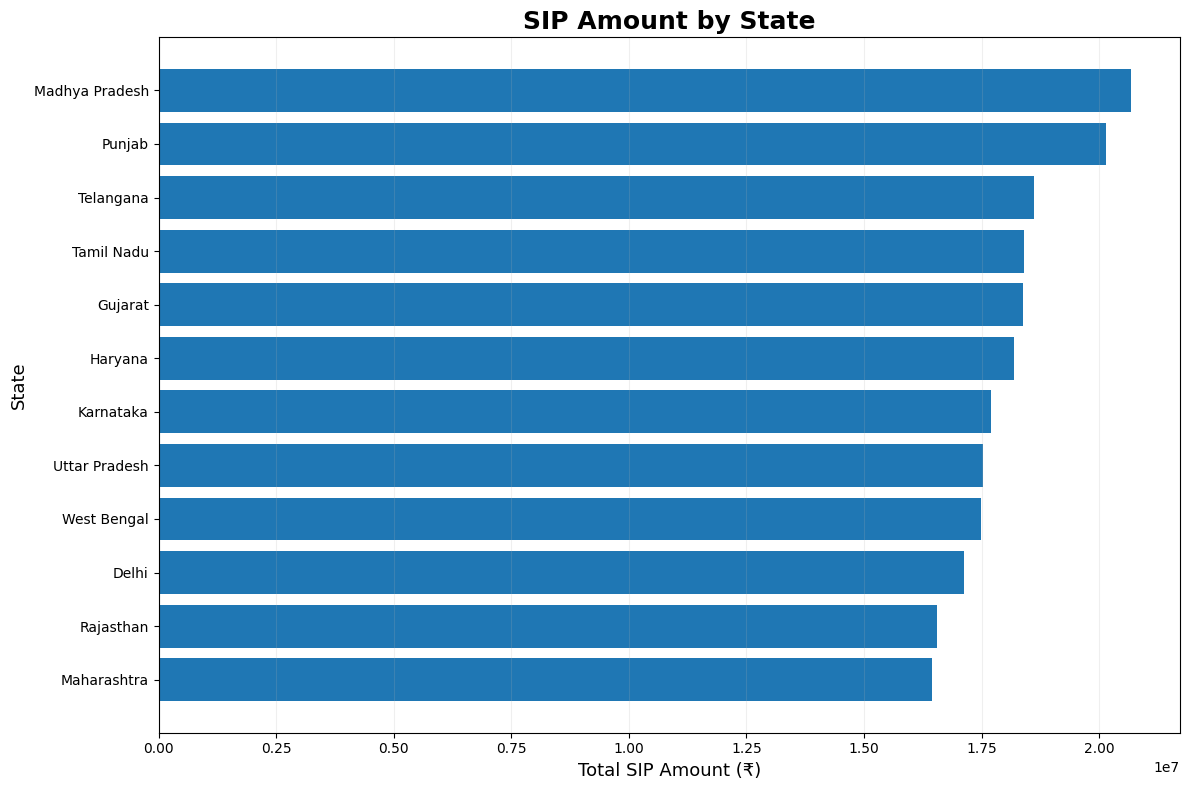

In [38]:
plt.figure(figsize=(12, 8))

plt.barh(
    sip_state.index,
    sip_state.values
)

plt.title(
    "SIP Amount by State",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Total SIP Amount (₹)",
    fontsize=13
)

plt.ylabel(
    "State",
    fontsize=13
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        charts_path,
        "Geo Distribution_sip_by_state.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Chart 2 — T30 vs B30

In [39]:
print(
    sip_transactions["city_tier"].value_counts()
)

city_tier
T30    13123
B30     6593
Name: count, dtype: int64


In [40]:
tier_sip_amount = (
    sip_transactions
    .groupby("city_tier")["amount_inr"]
    .sum()
)

print(tier_sip_amount)

city_tier
B30     72304870
T30    144928621
Name: amount_inr, dtype: int64


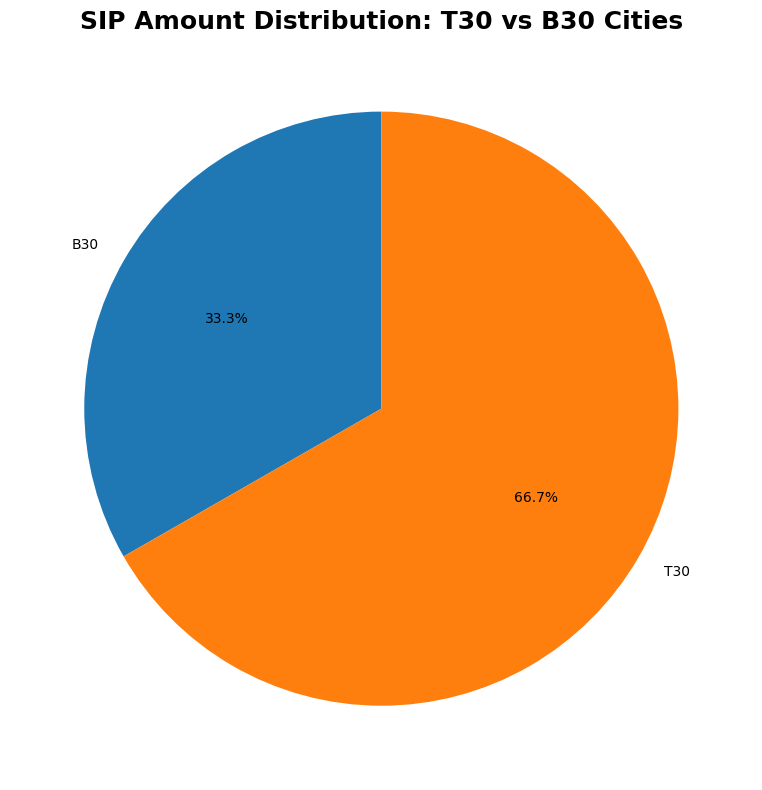

In [41]:
plt.figure(figsize=(8, 8))

plt.pie(
    tier_sip_amount.values,
    labels=tier_sip_amount.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "SIP Amount Distribution: T30 vs B30 Cities",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        charts_path,
        "Geo Distribution_t30_vs_b30.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Folio count growth: Line chart Jan 2022 to Dec 2025 showing growth from 13.26 to 26.12 crore.

In [42]:
# Convert month to datetime
folio["month"] = pd.to_datetime(
    folio["month"],
    errors="coerce"
)

# Sort by month
folio = folio.sort_values("month").reset_index(drop=True)

print("Date range:", folio["month"].min(), "to", folio["month"].max())
print("Number of records:", len(folio))

print("\nFirst record:")
print(folio.iloc[0])

print("\nLast record:")
print(folio.iloc[-1])

Date range: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
Number of records: 21

First record:
month                  2022-01-01 00:00:00
total_folios_crore                   13.26
equity_folios_crore                   9.28
debt_folios_crore                     1.86
hybrid_folios_crore                    0.8
others_folios_crore                   1.33
Name: 0, dtype: object

Last record:
month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object


In [43]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Folio Count Growth (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "total_folios_crore": "Total Folios (Crore)"
    }
)

# Line and marker formatting
fig.update_traces(
    line_width=3,
    marker_size=7
)

# Starting point
start_value = folio.iloc[0]["total_folios_crore"]
start_month = folio.iloc[0]["month"]

# Ending point
end_value = folio.iloc[-1]["total_folios_crore"]
end_month = folio.iloc[-1]["month"]

# Start milestone
fig.add_annotation(
    x=start_month,
    y=start_value,
    text=f"Jan 2022: {start_value:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=70,
    ay=-50,
    font=dict(size=13)
)

# 20 Cr milestone
milestone_20 = folio[
    folio["total_folios_crore"] >= 20
].iloc[0]

fig.add_annotation(
    x=milestone_20["month"],
    y=milestone_20["total_folios_crore"],
    text=f"20 Cr Milestone",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-60,
    font=dict(size=13)
)

# 25 Cr milestone
milestone_25 = folio[
    folio["total_folios_crore"] >= 25
].iloc[0]

fig.add_annotation(
    x=milestone_25["month"],
    y=milestone_25["total_folios_crore"],
    text="25 Cr Milestone",
    showarrow=True,
    arrowhead=2,
    ax=-70,
    ay=-50,
    font=dict(size=13)
)

# Ending point
fig.add_annotation(
    x=end_month,
    y=end_value,
    text=f"Dec 2025: {end_value:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    ax=-90,
    ay=-50,
    font=dict(size=13)
)

# Layout
fig.update_layout(
    width=1500,
    height=700,
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

# Interactive Plotly
fig.write_html(
    os.path.join(
        charts_path,
        "folio_count_growth.html"
    )
)




Correlation matrix: Compute pairwise correlation of NAV returns across 10 selected funds.

In [44]:
# Select 10 funds
selected_funds = (
    nav_analysis["amfi_code"]
    .drop_duplicates()
    .head(10)
    .tolist()
)

print("Selected AMFI codes:")
print(selected_funds)

Selected AMFI codes:
[100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886, 102887, 118632]


In [45]:
selected_scheme_names = (
    nav_analysis[
        nav_analysis["amfi_code"].isin(selected_funds)
    ][["amfi_code", "scheme_name"]]
    .drop_duplicates()
)

selected_scheme_names

,amfi_code,scheme_name
0,100016,HDFC Top 100 Fund - Regular Plan - Growth
1150,100025,HDFC Short Term Debt Fund - Regular - Growth
2300,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3450,101206,ABSL Frontline Equity Fund - Regular - Growth
4600,101207,ABSL Small Cap Fund - Regular - Growth
5750,101208,ABSL Liquid Fund - Regular - Growth
6900,102885,UTI Nifty 50 Index Fund - Regular - Growth
8050,102886,UTI Mid Cap Fund - Regular - Growth
9200,102887,UTI Flexi Cap Fund - Regular - Growth
10350,118632,Nippon India Large Cap Fund - Regular - Growth


In [46]:
nav_10 = nav_analysis[
    nav_analysis["amfi_code"].isin(selected_funds)
].copy()

nav_10 = nav_10.sort_values(
    ["amfi_code", "date"]
)

print("Records:", len(nav_10))
print("Funds:", nav_10["amfi_code"].nunique())

Records: 11500
Funds: 10


In [47]:
nav_10["daily_return"] = (
    nav_10
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [48]:
returns_matrix = nav_10.pivot(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

returns_matrix.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.001153,-0.000141,-0.010865,-0.013328,-0.003553,-0.010306,-0.000714,-0.010459,0.011314,0.011122
2022-01-05,0.003866,0.000382,0.000603,-0.004386,-0.000050,0.012865,0.005913,-0.005308,0.006779,-0.007878
2022-01-06,-0.002128,-0.000143,-0.029101,-0.005167,-0.001880,-0.011377,0.003540,0.012678,0.031127,0.015277
2022-01-07,-0.006314,0.000215,0.024766,-0.005748,0.002036,-0.001210,-0.005793,-0.016498,-0.008835,-0.009369


In [49]:
returns_clean = returns_matrix.dropna()

print("Original rows:", len(returns_matrix))
print("Rows after removing NaN:", len(returns_clean))

Original rows: 1150
Rows after removing NaN: 1149


In [50]:
returns_array = returns_clean.to_numpy()

correlation_matrix = np.corrcoef(
    returns_array,
    rowvar=False
)

correlation_df = pd.DataFrame(
    correlation_matrix,
    index=returns_clean.columns,
    columns=returns_clean.columns
)

correlation_df

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,-0.018079,0.023769,0.027747,-0.005432,-0.006490,0.007229,0.001570
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,0.007864,0.018455,-0.033773,0.003507,0.036547,0.014307,-0.001436
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.000351,-0.006710,0.016053,0.043384,0.002304,0.004860,-0.005929
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.018079,0.007864,0.000351,1.000000,0.002150,-0.000006,-0.013318,-0.036647,-0.018166,-0.034228
HDFC Short Term Debt Fund - Regular - Growth,0.023769,0.018455,-0.006710,0.002150,1.000000,0.045567,-0.014166,-0.005648,0.013754,-0.001038
HDFC Top 100 Fund - Regular Plan - Growth,0.027747,-0.033773,0.016053,-0.000006,0.045567,1.000000,-0.026781,-0.023316,-0.005867,-0.093533
Nippon India Large Cap Fund - Regular - Growth,-0.005432,0.003507,0.043384,-0.013318,-0.014166,-0.026781,1.000000,0.001248,-0.039886,-0.000285
UTI Flexi Cap Fund - Regular - Growth,-0.006490,0.036547,0.002304,-0.036647,-0.005648,-0.023316,0.001248,1.000000,-0.007865,-0.036704
UTI Mid Cap Fund - Regular - Growth,0.007229,0.014307,0.004860,-0.018166,0.013754,-0.005867,-0.039886,-0.007865,1.000000,0.020691


In [51]:
print("NaN values:", correlation_df.isna().sum().sum())

NaN values: 0


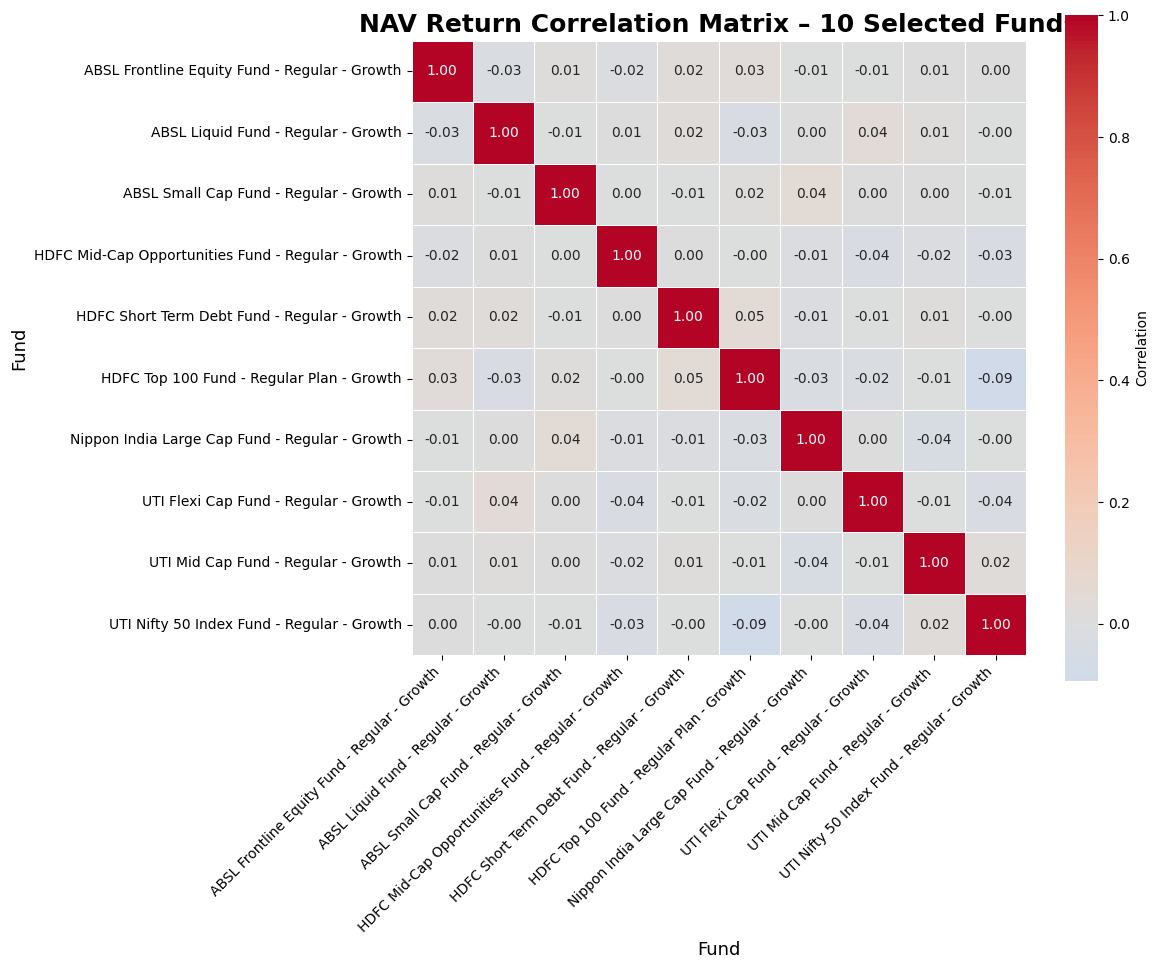

In [52]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "NAV Return Correlation Matrix – 10 Selected Funds",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Fund", fontsize=13)
plt.ylabel("Fund", fontsize=13)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(
        charts_path,
        "Correlation_Matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
print(portfolio.shape)
print(portfolio.columns.tolist())
portfolio.head()

(322, 8)
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [54]:
sector_allocation = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_allocation

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [55]:
print("Number of funds:", portfolio["amfi_code"].nunique())
print("Number of sectors:", portfolio["sector"].nunique())
print("\nSectors:")
print(portfolio["sector"].unique())

Number of funds: 34
Number of sectors: 14

Sectors:
['Utilities' 'Banking' 'Diversified' 'Pharma' 'Paints' 'Telecom' 'IT'
 'Automobile' 'NBFC' 'Cement' 'Energy' 'Consumer Goods' 'FMCG'
 'Infrastructure']


In [56]:
sector_allocation = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_allocation

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

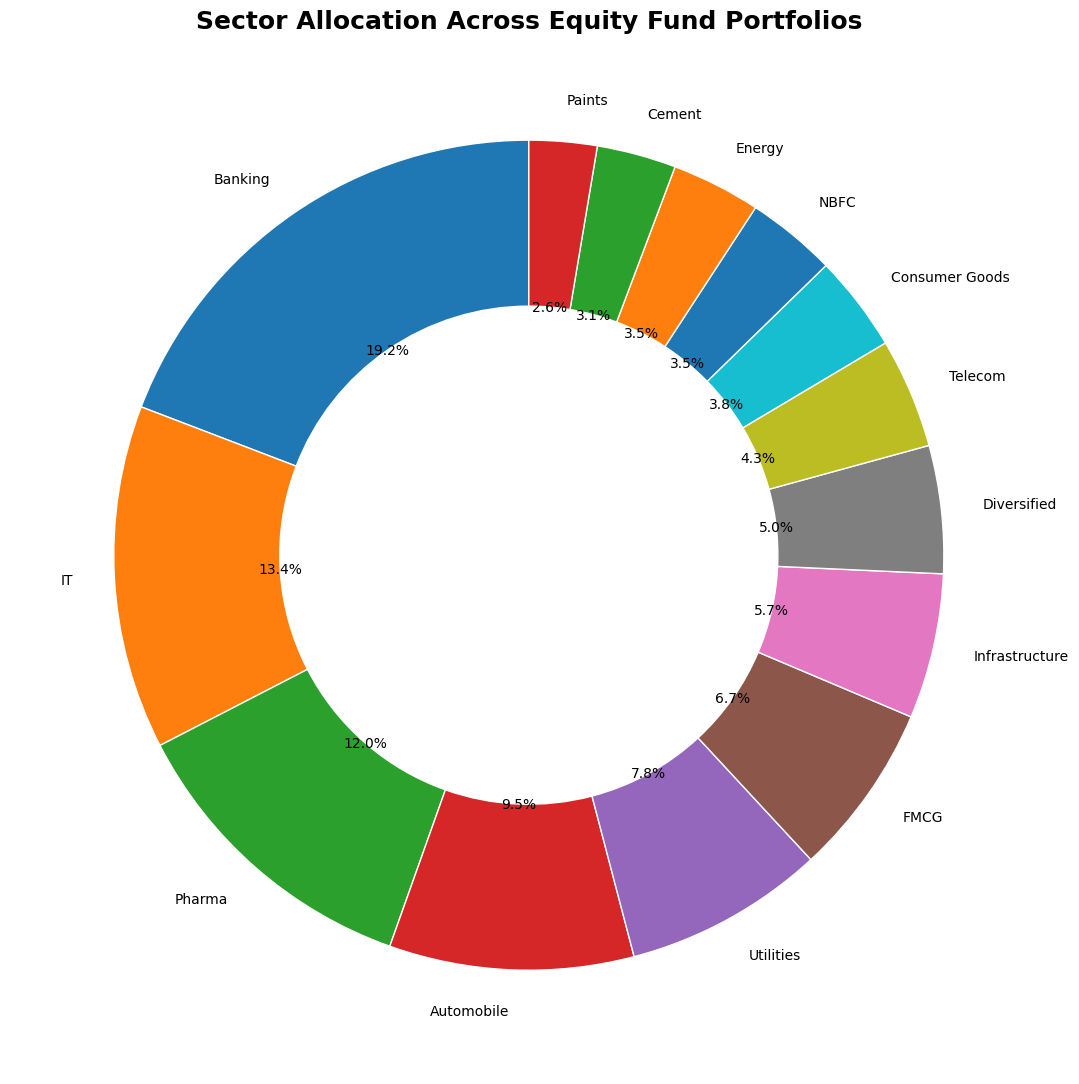

In [57]:
plt.figure(figsize=(11, 11))

plt.pie(
    sector_allocation,
    labels=sector_allocation.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor="white")
)

plt.title(
    "Sector Allocation Across Equity Fund Portfolios",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        charts_path,
        "Sector_Allocation.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()